# Deep Learning HW1
## 0. Environment Setup

To ensure reproducibility, we recommend creating a dedicated conda environment before running this notebook.

### Step 1. Create a new conda environment

```bash
conda create -n dl_hw1 python=3.11 -y
conda activate dl_hw1
```
### Step 2. Install PyTorch

First try installing the GPU version:
```bash
python -m pip install torch==2.5.0 torchvision==0.20.0 torchaudio==2.5.0 --index-url https://download.pytorch.org/whl/cu121
python -m pip install torch-geometric==2.6.1
python -m pip install numpy matplotlib tqdm jupyter
```

The next code is for check whether pytorch install well or not 
```bash
python -c "import sys; print(sys.executable)"
python -c "import torch; print(torch.__version__)"
python -c "import torch; print(torch.cuda.is_available())"
python -c "import torch_geometric; print(torch_geometric.__version__)"
python -c "import numpy; print(numpy.__version__)"
```



Environment Check
Run the following code cell to verify the environment.

In [1]:
import torch
import sys
import numpy as np

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0]
PyTorch: 2.5.0+cu121
NumPy: 2.3.5
CUDA available: True
Using device: cuda
GPU: NVIDIA GeForce RTX 4090


## 1. Problem Setup and Data Preparation

In this section, we define the ordinary differential equation (ODE) considered in this assignment, its exact solution, and the default experimental setting.  
We also implement helper functions to generate training data and evaluation data.

- The random seed is fixed to `0` to ensure reproducibility.
- Training samples are generated by uniformly sampling `t` from `[0,1]`.
- The exact solution is used to construct the corresponding target values.

In [2]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import time

# ============================================================
# 기본 환경 설정
# - random seed 고정
# - device 설정
# ============================================================
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


# ============================================================
# 문제 설정
# - ODE: du/dt = -a u, u(0)=1
# - exact solution: u(t) = exp(-a t)
# ============================================================
A_TRUE = 2.0
N_TRAIN_DEFAULT = 20
T_MIN, T_MAX = 0.0, 1.0
EPS = 1e-12

DEFAULT_CONFIG = {
    "hidden_dim": 32,
    "depth": 1,            # hidden layer 개수
    "activation": "tanh",
    "optimizer": "Adam",
    "lr": 1e-3,
    "k_fold": 1,
    "train_size": 20,
    "n_iters": 5000,
    "seed": 0,
}

device: cuda


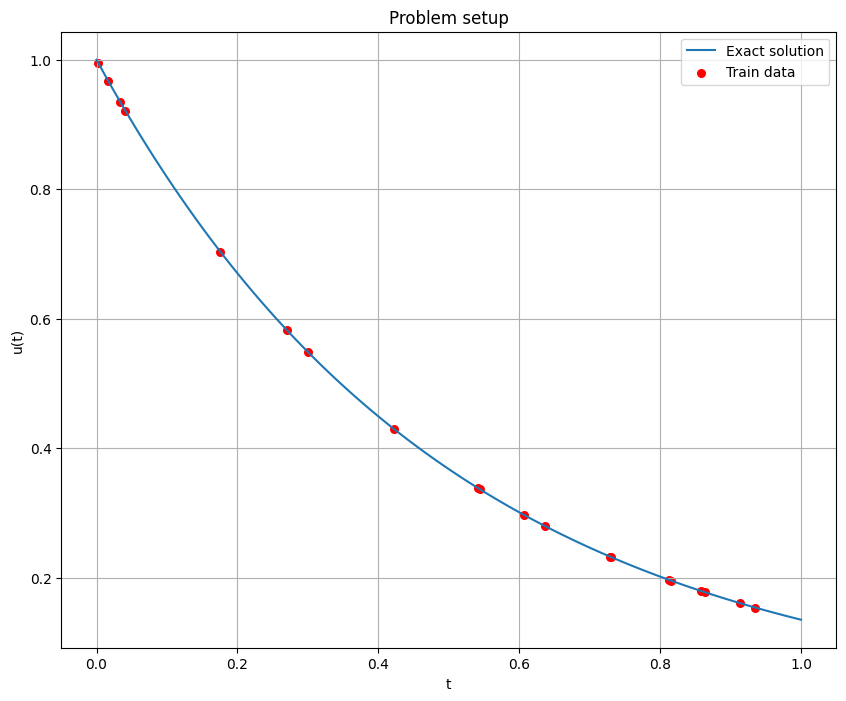

In [3]:
# ============================================================
# exact solution
# - numpy, torch 둘 다 처리 가능하게 작성
# ============================================================
def exact_solution(t, a=A_TRUE):
    if isinstance(t, np.ndarray):
        return np.exp(-a * t)
    return torch.exp(-a * t)


# ============================================================
# 데이터 생성 함수
# - train data: [0,1]에서 uniform sampling
# ============================================================
def generate_train_data(n_train=20, a=A_TRUE, t_min=T_MIN, t_max=T_MAX, seed=0):
    rng = np.random.default_rng(seed)
    t = rng.uniform(t_min, t_max, size=(n_train, 1))
    t = np.sort(t, axis=0)
    u = exact_solution(t, a=a)

    t_tensor = torch.tensor(t, dtype=torch.float32)
    u_tensor = torch.tensor(u, dtype=torch.float32)
    return t_tensor, u_tensor

def generate_eval_grid(n_eval, t_min=T_MIN, t_max=T_MAX, a=A_TRUE):
    t = np.linspace(t_min, t_max, n_eval).reshape(-1, 1)
    u = exact_solution(t, a=a)

    t_tensor = torch.tensor(t, dtype=torch.float32)
    u_tensor = torch.tensor(u, dtype=torch.float32)
    return t_tensor, u_tensor

# quick visualization
t_train, u_train = generate_train_data(n_train=N_TRAIN_DEFAULT, seed=0)
t_eval, u_eval = generate_eval_grid(n_eval = 100)

plt.figure(figsize=(10, 8))
plt.plot(t_eval.numpy(), u_eval.numpy(), label="Exact solution")
plt.scatter(t_train.numpy(), u_train.numpy(), color="red", s=30, label="Train data")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Problem setup")
plt.legend()
plt.grid(True)
plt.show()

## 2. Network and Training Utilities

In this section, we implement the core components required for the regression experiments.

These include:

- the MLP model,
- the optimizer builder,
- the regression loss,
- the relative \(L_2\) error,
- manual K-fold cross validation,
- and the training function.

All analyses in later sections will reuse these functions.

In [4]:
# ============================================================
# Model
# - depth = number of hidden layers
# - depth = 0 means a linear model without hidden layers
# ============================================================
class MLP(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=32, depth=1, out_dim=1, activation="tanh"):
        super().__init__()

        if activation == "tanh":
            act_layer = nn.Tanh
        elif activation == "relu":
            act_layer = nn.ReLU
        elif activation == "gelu":
            act_layer = nn.GELU
        elif activation == "sigmoid":
            act_layer = nn.Sigmoid
        else:
            raise ValueError(f"Unsupported activation: {activation}")

        # ============================================================
        # TODO:
        # Build the neural network architecture.
        #
        # Requirements:
        # 1. If depth == 0, construct a linear model:
        #       Linear(in_dim -> out_dim)
        #
        # 2. If depth >= 1, construct an MLP with:
        #       - one input layer: Linear(in_dim -> hidden_dim)
        #       - 'depth' hidden layers in total
        #       - one output layer: Linear(hidden_dim -> out_dim)
        #       - the chosen activation function after each hidden layer
        #
        # Expected behavior:
        # - depth controls the number of hidden layers
        # - hidden_dim controls the width of each hidden layer
        # ============================================================
        layers = []

        if depth == 0:
            layers.append(nn.Linear(in_dim, out_dim))
        else:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(act_layer())

            for _ in range(depth - 1):
                layers.append(nn.Linear(hidden_dim, hidden_dim))
                layers.append(act_layer())

            layers.append(nn.Linear(hidden_dim, out_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [5]:
# ============================================================
# Optimizer
# - Build an optimizer from its name
# ============================================================
def build_optimizer(model, optimizer_name="Adam", lr=1e-3):
    # ============================================================
    # TODO:
    # Return the correct optimizer based on optimizer_name.
    #
    # Supported optimizers:
    # - "SGD"
    # - "Adam"
    # - "AdamW"
    #
    # Expected behavior:
    # - All optimizers should optimize model.parameters()
    # - The learning rate should be set by lr
    # ============================================================
    if optimizer_name == "SGD":
        return torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "Adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "AdamW":
        return torch.optim.AdamW(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")


In [6]:
# ============================================================
# Loss and metrics
# ============================================================
def regression_loss(model, t, u):
    # ============================================================
    # TODO:
    # Compute the Mean Squared Error (MSE) loss for regression.
    #
    # Steps:
    # 1. Compute the prediction u_pred = model(t)
    # 2. Compute the MSE loss:
    #       (1/N) * sum_i (u_pred_i - u_i)^2
    #
    # Expected behavior:
    # - The returned value should be a scalar tensor
    # - This loss will be used for backpropagation
    # ============================================================
    u_pred = model(t)
    mse = torch.mean((u_pred - u) ** 2)
    return mse


In [7]:
def relative_l2_error(u_pred, u_true, eps=EPS):
    # ============================================================
    # TODO:
    # Compute the relative L2 error:
    #
    #   ||u_pred - u_true||_2 / ||u_true||_2
    #
    # Requirements:
    # - Add eps to the denominator for numerical stability
    # ============================================================
    numerator = torch.sqrt(torch.sum((u_pred - u_true) ** 2))
    denominator = torch.sqrt(torch.sum(u_true ** 2)) + eps
    return (numerator / denominator).item()


In [13]:
# ============================================================
# Manual K-fold split
# - Build train/validation indices without external packages
# ============================================================
def build_kfold_indices(n_samples, k=5, shuffle=True, seed=0):
    indices = np.arange(n_samples)

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)

    # ============================================================
    # TODO:
    # Split the dataset indices into K folds manually.
    #
    # Steps:
    # 1. Compute the size of each fold
    # 2. For each fold:
    #    - use one part as validation indices
    #    - use the remaining parts as training indices
    # 3. Return a list of (train_idx, val_idx) pairs
    #
    # Expected behavior:
    # - The function should work even when n_samples is not divisible by k
    # - The first few folds may contain one extra sample
    # ============================================================
    fold_sizes = np.full(k, n_samples // k, dtype=int)
    fold_sizes[: n_samples % k] += 1

    folds = []
    current = 0

    for fold_size in fold_sizes:
        start = current
        end = current + fold_size

        val_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])

        folds.append((train_idx, val_idx))
        current = end

    return folds

In [14]:
# ============================================================
# 결과 저장 폴더
# - results/regression 아래에 각 설정별 폴더 생성
# ============================================================
RESULT_ROOT = Path("results/regression")
RESULT_ROOT.mkdir(parents=True, exist_ok=True)


def make_run_name(config):
    # 설정을 문자열로 만들어 폴더 이름 생성
    return (
        f"h{config['hidden_dim']}_"
        f"d{config['depth']}_"
        f"act{config['activation']}_"
        f"opt{config['optimizer']}_"
        f"lr{config['lr']}_"
        f"k{config['k_fold']}_"
        f"n{config['train_size']}_"
        f"it{config['n_iters']}_"
        f"seed{config['seed']}"
    )


# ============================================================
# Train one run
# - Train one configuration
# - Skip if the same configuration was already trained
# - Save both model parameters and summary results
# ============================================================
def train_single_run(config):
    run_name = make_run_name(config)
    run_dir = RESULT_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    model_path = run_dir / "model.pt"
    result_path = run_dir / "result.json"

    if model_path.exists() and result_path.exists():
        print(f"[SKIP] Already trained: {run_name}")
        with open(result_path, "r", encoding="utf-8") as f:
            result = json.load(f)
        return result

    print(f"[TRAIN] Start: {run_name}")
    set_seed(config["seed"])

    t_all, u_all = generate_train_data(
        n_train=config["train_size"],
        a=A_TRUE,
        seed=config["seed"]
    )

    if config["k_fold"] == 1:
        folds = [(np.arange(len(t_all)), np.arange(len(t_all)))]
    else:
        folds = build_kfold_indices(
            n_samples=len(t_all),
            k=config["k_fold"],
            shuffle=True,
            seed=config["seed"]
        )

    fold_results = []

    for fold_id, (train_idx, val_idx) in enumerate(folds):
        t_train = t_all[train_idx].to(device)
        u_train = u_all[train_idx].to(device)
        t_val = t_all[val_idx].to(device)
        u_val = u_all[val_idx].to(device)

        model = MLP(
            hidden_dim=config["hidden_dim"],
            depth=config["depth"],
            activation=config["activation"]
        ).to(device)

        optimizer = build_optimizer(
            model,
            optimizer_name=config["optimizer"],
            lr=config["lr"]
        )

        history = {
            "iter": [],
            "train_loss": [],
            "val_loss": [],
            "val_rel_l2": [],
            "elapsed_time": [],
        }

        start_time = time.time()
        log_every = max(1, config["n_iters"] // 10)

        # ========================================================
        # TODO:
        # Implement the training loop.
        #
        # At each iteration:
        # 1. Set the model to train mode
        # 2. Clear previous gradients
        # 3. Compute the training loss
        # 4. Perform backpropagation
        # 5. Update the model parameters
        #
        # Then evaluate on the validation set:
        # 6. Set the model to eval mode
        # 7. Compute validation MSE loss
        # 8. Compute validation relative L2 error
        # 9. Store all values in history
        #
        # Logging:
        # - Print the following every n_iters // 10 iterations:
        #   [current_iter / total_iter]
        #   Train loss: ...
        #   Validation loss: ...
        #   Validation Rel L2: ...
        #   Training time: ...
        # ========================================================
        for it in range(1, config["n_iters"] + 1):
            model.train()
            optimizer.zero_grad()

            loss = regression_loss(model, t_train, u_train)
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                u_val_pred = model(t_val)
                val_loss = torch.mean((u_val_pred - u_val) ** 2)
                val_rel_l2 = relative_l2_error(u_val_pred, u_val)

            elapsed = time.time() - start_time

            history["iter"].append(it)
            history["train_loss"].append(loss.item())
            history["val_loss"].append(val_loss.item())
            history["val_rel_l2"].append(val_rel_l2)
            history["elapsed_time"].append(elapsed)

            if (it % log_every == 0) or (it == config["n_iters"]):
                print(
                    f"[{it}/{config['n_iters']}] "
                    f"Train loss: {loss.item():.6e}, "
                    f"Validation loss: {val_loss.item():.6e}, "
                    f"Validation Rel L2: {val_rel_l2:.6e}, "
                    f"Training time: {elapsed:.2f}s"
                )

        fold_result = {
            "fold_id": int(fold_id),
            "val_rel_l2": float(history["val_rel_l2"][-1]),
            "history": history
        }
        fold_results.append(fold_result)

    torch.save(model.state_dict(), model_path)

    result = {
        "config": config,
        "fold_results": fold_results,
        "mean_val_rel_l2": float(np.mean([fr["val_rel_l2"] for fr in fold_results])),
        "std_val_rel_l2": float(np.std([fr["val_rel_l2"] for fr in fold_results]))
    }

    with open(result_path, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    print(f"[DONE] Saved to: {run_dir}")
    return result

## 3. Basic Training Run

In this section, we run a single training experiment using the default setting and check whether the full pipeline works correctly.
This step helps verify that the model, loss, optimizer, and saving procedure are implemented properly before running larger analyses.

In [15]:
# ============================================================
# Default run
# ============================================================
default_result = train_single_run(DEFAULT_CONFIG)
print(default_result["mean_val_rel_l2"], default_result["std_val_rel_l2"])

[TRAIN] Start: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[500/5000] Train loss: 4.486134e-03, Validation loss: 4.484618e-03, Validation Rel L2: 1.258504e-01, Training time: 0.63s
[1000/5000] Train loss: 3.380245e-03, Validation loss: 3.377232e-03, Validation Rel L2: 1.092125e-01, Training time: 1.21s
[1500/5000] Train loss: 1.564023e-03, Validation loss: 1.560243e-03, Validation Rel L2: 7.423148e-02, Training time: 1.81s
[2000/5000] Train loss: 2.455361e-04, Validation loss: 2.442994e-04, Validation Rel L2: 2.937333e-02, Training time: 2.42s
[2500/5000] Train loss: 1.750487e-05, Validation loss: 1.743710e-05, Validation Rel L2: 7.847461e-03, Training time: 3.11s
[3000/5000] Train loss: 7.561601e-06, Validation loss: 7.556373e-06, Validation Rel L2: 5.165932e-03, Training time: 3.72s
[3500/5000] Train loss: 5.597561e-06, Validation loss: 5.594497e-06, Validation Rel L2: 4.445008e-03, Training time: 4.34s
[4000/5000] Train loss: 4.404318e-06, Validation loss: 4.402503e-06, Valid

In [16]:
# ============================================================
# Example: compare K values
# ============================================================
k_list = [1, 5, N_TRAIN_DEFAULT]  # K=1, K=5, LOOCV

k_results = []
for k in k_list:
    config = DEFAULT_CONFIG.copy()
    config["k_fold"] = k
    result = train_single_run(config)
    k_results.append(result)

for result in k_results:
    print(
        f"K={result['config']['k_fold']}, "
        f"mean_rel_l2={result['mean_val_rel_l2']:.6e}, "
        f"std_rel_l2={result['std_val_rel_l2']:.6e}"
    )

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[TRAIN] Start: h32_d1_acttanh_optAdam_lr0.001_k5_n20_it5000_seed0
[500/5000] Train loss: 4.202975e-03, Validation loss: 6.047369e-03, Validation Rel L2: 1.194664e-01, Training time: 0.63s
[1000/5000] Train loss: 3.200038e-03, Validation loss: 4.708255e-03, Validation Rel L2: 1.054126e-01, Training time: 1.27s
[1500/5000] Train loss: 1.554089e-03, Validation loss: 2.438744e-03, Validation Rel L2: 7.586573e-02, Training time: 1.90s
[2000/5000] Train loss: 2.726148e-04, Validation loss: 5.378948e-04, Validation Rel L2: 3.562962e-02, Training time: 2.54s
[2500/5000] Train loss: 1.749913e-05, Validation loss: 8.181137e-05, Validation Rel L2: 1.389535e-02, Training time: 3.15s
[3000/5000] Train loss: 5.955657e-06, Validation loss: 3.904355e-05, Validation Rel L2: 9.599247e-03, Training time: 3.76s
[3500/5000] Train loss: 4.595619e-06, Validation loss: 2.917169e-05, Validation Rel L2: 8.297425e-03, Training time: 4.41s

## 4. Analysis Utilities

In this section, we define reusable functions for loading saved results, evaluating trained models on a uniform grid, and visualizing the outputs.

These helper functions will be used in the following analyses:

- optimizer analysis,
- learning rate analysis,
- network width analysis,
- network depth analysis,
- activation function analysis,
- training data size analysis,
- and K-fold cross validation analysis.

In [17]:
# ============================================================
# Example: run multiple settings automatically
# ============================================================
optimizer_list = ["SGD", "Adam", "AdamW"]
lr_list = [1e-2, 1e-3, 1e-4]
hidden_dims = [4, 16, 32, 64]
depths = [0, 1, 2]
activations = ["tanh", "relu", "sigmoid"]

all_results = []

# optimizer sweep
for opt_name in optimizer_list:
    config = DEFAULT_CONFIG.copy()
    config["optimizer"] = opt_name
    result = train_single_run(config)
    all_results.append(result)

# learning rate sweep
for lr in lr_list:
    config = DEFAULT_CONFIG.copy()
    config["lr"] = lr
    result = train_single_run(config)
    all_results.append(result)

# hidden width sweep
for h in hidden_dims:
    config = DEFAULT_CONFIG.copy()
    config["hidden_dim"] = h
    result = train_single_run(config)
    all_results.append(result)

# depth sweep
for d in depths:
    config = DEFAULT_CONFIG.copy()
    config["depth"] = d
    result = train_single_run(config)
    all_results.append(result)

# activation sweep
for act in activations:
    config = DEFAULT_CONFIG.copy()
    config["activation"] = act
    result = train_single_run(config)
    all_results.append(result)

# training data size sweep
for n in [5, 10, 20, 50, 100]:
    config = DEFAULT_CONFIG.copy()
    config["train_size"] = n
    result = train_single_run(config)
    all_results.append(result)

[SKIP] Already trained: h32_d1_acttanh_optSGD_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[TRAIN] Start: h32_d1_acttanh_optAdamW_lr0.001_k1_n20_it5000_seed0
[500/5000] Train loss: 4.484687e-03, Validation loss: 4.483187e-03, Validation Rel L2: 1.258304e-01, Training time: 0.66s
[1000/5000] Train loss: 3.400287e-03, Validation loss: 3.397343e-03, Validation Rel L2: 1.095372e-01, Training time: 1.31s
[1500/5000] Train loss: 1.614599e-03, Validation loss: 1.610841e-03, Validation Rel L2: 7.542554e-02, Training time: 2.02s
[2000/5000] Train loss: 2.735922e-04, Validation loss: 2.722777e-04, Validation Rel L2: 3.100974e-02, Training time: 2.61s
[2500/5000] Train loss: 2.183506e-05, Validation loss: 2.175072e-05, Validation Rel L2: 8.764533e-03, Training time: 3.34s
[3000/5000] Train loss: 9.083140e-06, Validation loss: 9.076842e-06, Validation Rel L2: 5.661863e-03, Training time: 3.94s
[3500/5000] Train loss: 6.815989e-06, Validatio

## 5. Hyperparameter Analysis

In this section, we compare the training dynamics and prediction accuracy under different hyperparameter settings.

For each analysis, we visualize:

- the training loss curve,
- the prediction together with the exact solution,
- the pointwise relative error,
- and the relative $L_2$ error.

In [19]:
# ============================================================
# 결과 불러오기
# ============================================================
def load_result(config):
    run_name = make_run_name(config)
    run_dir = RESULT_ROOT / run_name
    result_path = run_dir / "result.json"
    model_path = run_dir / "model.pt"

    if not result_path.exists():
        raise FileNotFoundError(f"Result file not found: {result_path}")
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")

    with open(result_path, "r", encoding="utf-8") as f:
        result = json.load(f)

    model = MLP(
        hidden_dim=config["hidden_dim"],
        depth=config["depth"],
        activation=config["activation"]
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    return result, model


# ============================================================
# evaluation data 생성
# - Analysis에서는 [0,1] 구간의 uniform grid 사용
# ============================================================
def generate_analysis_grid(n_eval=200, t_min=T_MIN, t_max=T_MAX, a=A_TRUE):
    t = np.linspace(t_min, t_max, n_eval).reshape(-1, 1)
    u = exact_solution(t, a=a)

    t_tensor = torch.tensor(t, dtype=torch.float32).to(device)
    u_tensor = torch.tensor(u, dtype=torch.float32).to(device)
    return t_tensor, u_tensor


# ============================================================
# 모델 예측과 error 계산
# ============================================================
def pointwise_relative_error(u_pred, u_true, eps=1e-12):
    return torch.abs(u_pred - u_true) / (torch.abs(u_true) + eps)

def evaluate_model_on_grid(model, n_eval=200):
    t_grid, u_exact = generate_analysis_grid(n_eval=n_eval)

    with torch.no_grad():
        u_pred = model(t_grid)

    rel_l2 = relative_l2_error(u_pred, u_exact)
    pw_rel = pointwise_relative_error(u_pred, u_exact).detach().cpu().numpy()

    return {
        "t": t_grid.detach().cpu().numpy(),
        "u_exact": u_exact.detach().cpu().numpy(),
        "u_pred": u_pred.detach().cpu().numpy(),
        "pointwise_rel_error": pw_rel,
        "relative_l2": rel_l2
    }

#### 3.2 공통 Plot 함수
여러 설정을 한 번에 비교할 수 있도록 공통 plotting 함수를 정의한다. 겹치는 선들도 비교 가능하도록 linewidth와 alpha를 조절한다.

In [20]:
# ============================================================
# 공통 plot style
# ============================================================
DEFAULT_LINEWIDTH = 2.0
DEFAULT_ALPHA = 0.75
EXACT_LINEWIDTH = 3.0
EXACT_ALPHA = 0.9


# ============================================================
# Training loss plot
# ============================================================
def plot_training_loss_comparison(results_dict, title="Training Loss Comparison"):
    plt.figure(figsize=(7, 4))

    for label, result in results_dict.items():
        history = result["fold_results"][0]["history"]
        plt.plot(
            history["iter"],
            history["train_loss"],
            label=label,
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA
        )

    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Training Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================================
# Prediction vs exact plot
# ============================================================
def plot_prediction_vs_exact(eval_dict, title="Prediction vs Exact"):
    plt.figure(figsize=(7, 4))

    # exact solution 먼저 그림
    first_key = list(eval_dict.keys())[0]
    plt.plot(
        eval_dict[first_key]["t"],
        eval_dict[first_key]["u_exact"],
        label="Exact",
        linewidth=EXACT_LINEWIDTH,
        alpha=EXACT_ALPHA,
        color="black"
    )

    # 각 설정별 prediction
    for label, out in eval_dict.items():
        plt.plot(
            out["t"],
            out["u_pred"],
            label=label,
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA
        )

    plt.xlabel("t")
    plt.ylabel("u(t)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================================
# Pointwise relative error plot
# ============================================================
def plot_pointwise_relative_error(eval_dict, title="Pointwise Relative Error"):
    plt.figure(figsize=(7, 4))

    for label, out in eval_dict.items():
        plt.plot(
            out["t"],
            out["pointwise_rel_error"],
            label=label,
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA
        )

    plt.xlabel("t")
    plt.ylabel("Pointwise Relative Error")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================================
# Relative L2 bar plot
# ============================================================
def plot_relative_l2_bar(eval_dict, title="Relative L2 Error"):
    labels = list(eval_dict.keys())
    values = [eval_dict[label]["relative_l2"] for label in labels]

    plt.figure(figsize=(7, 4))
    plt.bar(labels, values, alpha=0.8)
    plt.ylabel("Relative L2 Error")
    plt.title(title)
    plt.grid(True, axis="y")
    plt.show()


# ============================================================
# Relative L2 value print
# ============================================================
def print_relative_l2_table(eval_dict):
    print(f"{'Setting':<20} {'Relative L2 Error':<20}")
    print("-" * 40)
    for label, out in eval_dict.items():
        print(f"{label:<20} {out['relative_l2']:<20.6e}")

#### 4. Hyperparameter Analysis
##### 4.1 Optimizer Analysis
optimizer를 바꾸었을 때 training loss, pointwise relative error, relative L2 error, prediction curve가 어떻게 달라지는지 비교한다

[SKIP] Already trained: h32_d1_acttanh_optSGD_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdamW_lr0.001_k1_n20_it5000_seed0


/tmp/ipykernel_13158/1867590021.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


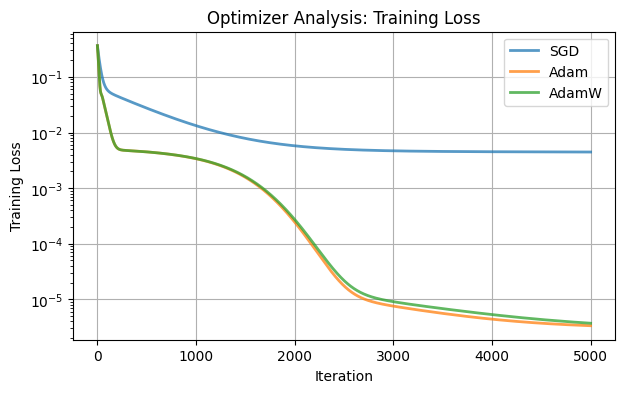

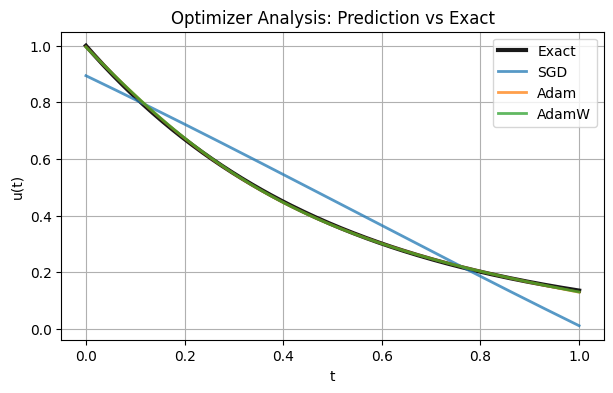

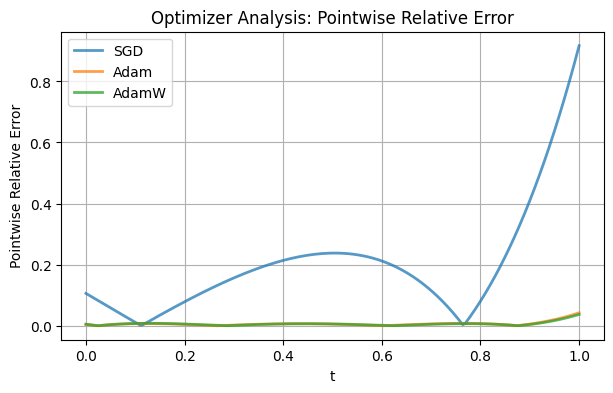

Setting              Relative L2 Error   
----------------------------------------
SGD                  1.385799e-01        
Adam                 5.291088e-03        
AdamW                5.495466e-03        


In [21]:
# ============================================================
# Optimizer Analysis
# ============================================================
optimizer_list = ["SGD", "Adam", "AdamW"]
optimizer_results = {}
optimizer_eval = {}

for opt_name in optimizer_list:
    config = DEFAULT_CONFIG.copy()
    config["optimizer"] = opt_name

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    optimizer_results[opt_name] = loaded_result
    optimizer_eval[opt_name] = eval_out

plot_training_loss_comparison(optimizer_results,title="Optimizer Analysis: Training Loss")
plot_prediction_vs_exact(optimizer_eval,title="Optimizer Analysis: Prediction vs Exact")
plot_pointwise_relative_error(optimizer_eval,title="Optimizer Analysis: Pointwise Relative Error")

print_relative_l2_table(optimizer_eval)

##### 4.2 Learning Rate Analysis
learning rate 변화에 따른 training dynamics와 prediction accuracy를 비교한다

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.01_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.0001_k1_n20_it5000_seed0


/tmp/ipykernel_13158/1867590021.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


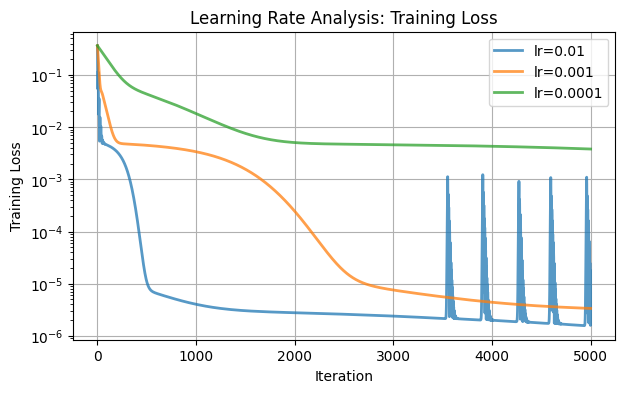

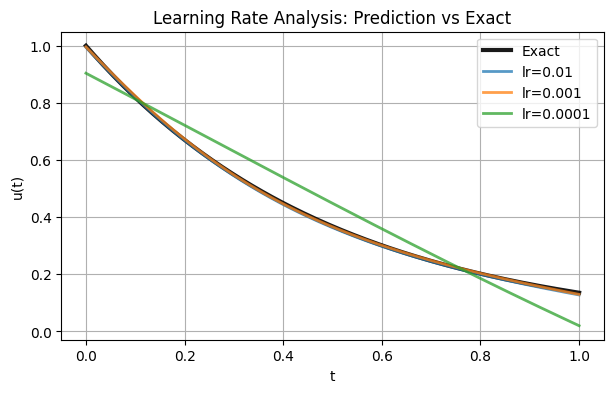

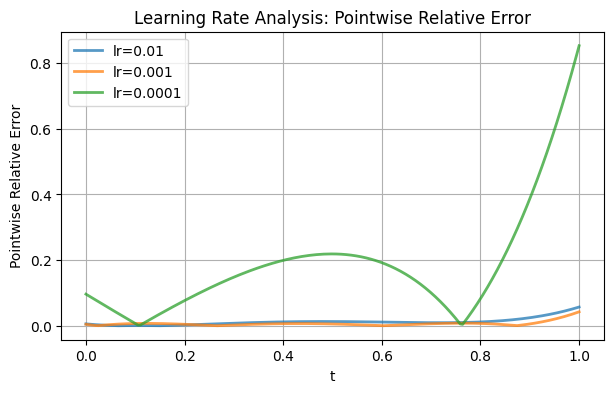

Setting              Relative L2 Error   
----------------------------------------
lr=0.01              7.505275e-03        
lr=0.001             5.291088e-03        
lr=0.0001            1.289164e-01        


In [22]:
# ============================================================
# Learning Rate Analysis
# ============================================================
lr_list = [1e-2, 1e-3, 1e-4]

lr_results = {}
lr_eval = {}

for lr in lr_list:
    config = DEFAULT_CONFIG.copy()
    config["lr"] = lr

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"lr={lr}"
    lr_results[label] = loaded_result
    lr_eval[label] = eval_out

plot_training_loss_comparison(
    lr_results,
    title="Learning Rate Analysis: Training Loss"
)

plot_prediction_vs_exact(
    lr_eval,
    title="Learning Rate Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    lr_eval,
    title="Learning Rate Analysis: Pointwise Relative Error"
)

print_relative_l2_table(lr_eval)

##### 4.3 Network Width Analysis
hidden width를 4, 16, 32, 64로 바꾸면서 network capacity가 결과에 미치는 영향을 비교한다.

[SKIP] Already trained: h4_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h16_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h64_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0


/tmp/ipykernel_13158/1867590021.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


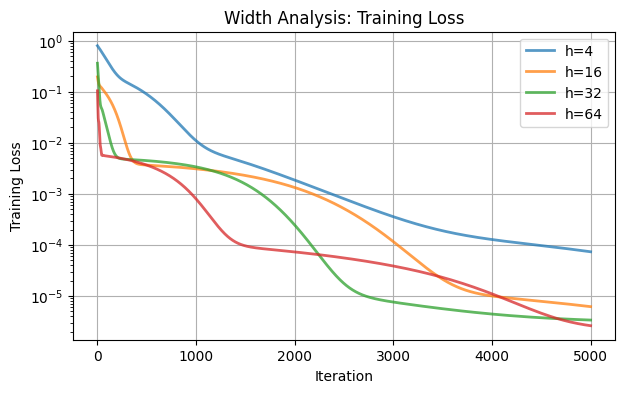

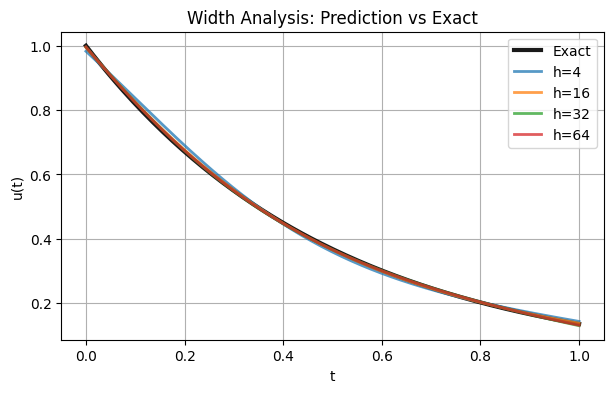

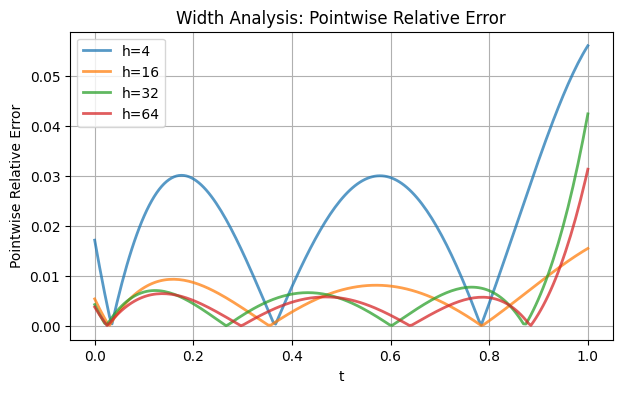

Setting              Relative L2 Error   
----------------------------------------
h=4                  2.057500e-02        
h=16                 6.264667e-03        
h=32                 5.291088e-03        
h=64                 4.559055e-03        


In [23]:
# ============================================================
# Network Width Analysis
# ============================================================
width_list = [4, 16, 32, 64]

width_results = {}
width_eval = {}

for h in width_list:
    config = DEFAULT_CONFIG.copy()
    config["hidden_dim"] = h

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"h={h}"
    width_results[label] = loaded_result
    width_eval[label] = eval_out

plot_training_loss_comparison(
    width_results,
    title="Width Analysis: Training Loss"
)

plot_prediction_vs_exact(
    width_eval,
    title="Width Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    width_eval,
    title="Width Analysis: Pointwise Relative Error"
)

print_relative_l2_table(width_eval)

##### 4.4 Network Depth Analysis
hidden layer 개수(depth)를 0, 1, 2로 바꾸면서 network depth의 효과를 비교한다. depth=0은 hidden layer 없는 linear model이다

[SKIP] Already trained: h32_d0_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d2_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0


/tmp/ipykernel_13158/1867590021.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


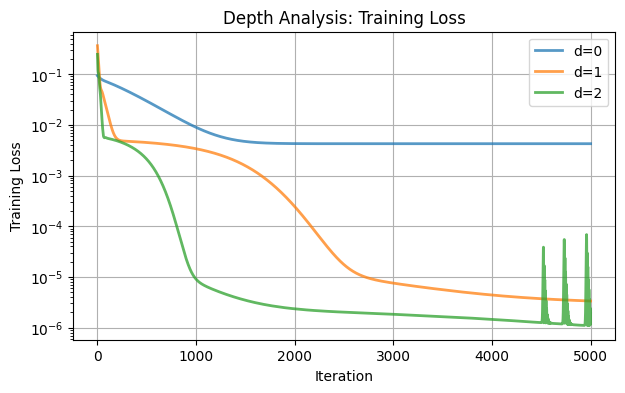

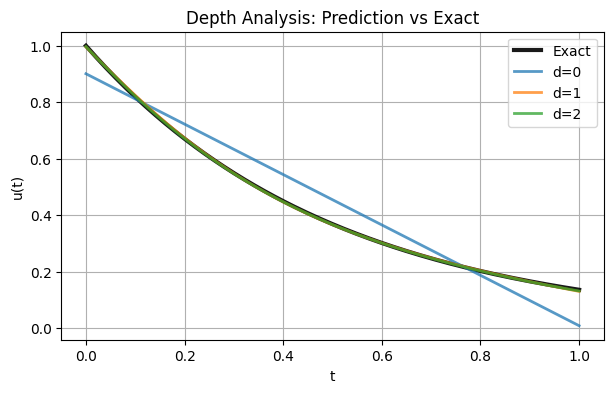

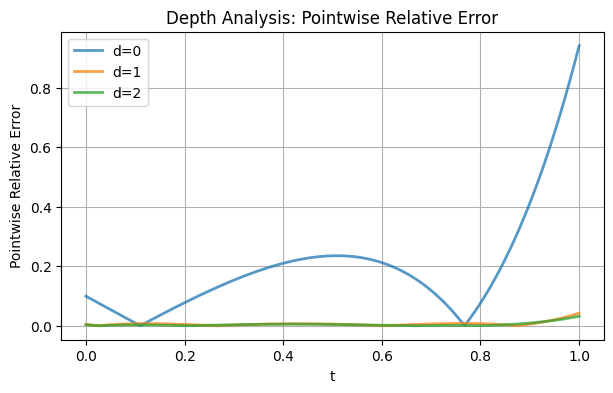

Setting              Relative L2 Error   
----------------------------------------
d=0                  1.370402e-01        
d=1                  5.291088e-03        
d=2                  3.319287e-03        


In [24]:
# ============================================================
# Network Depth Analysis
# ============================================================
depth_list = [0, 1, 2]

depth_results = {}
depth_eval = {}

for d in depth_list:
    config = DEFAULT_CONFIG.copy()
    config["depth"] = d

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"d={d}"
    depth_results[label] = loaded_result
    depth_eval[label] = eval_out

plot_training_loss_comparison(
    depth_results,
    title="Depth Analysis: Training Loss"
)

plot_prediction_vs_exact(
    depth_eval,
    title="Depth Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    depth_eval,
    title="Depth Analysis: Pointwise Relative Error"
)

print_relative_l2_table(depth_eval)

##### 4.5 Activation function analysis
activation function을 바꾸면서 training dynamics와 prediction accuracy를 비교한다

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_actrelu_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_actsigmoid_optAdam_lr0.001_k1_n20_it5000_seed0


/tmp/ipykernel_13158/1867590021.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


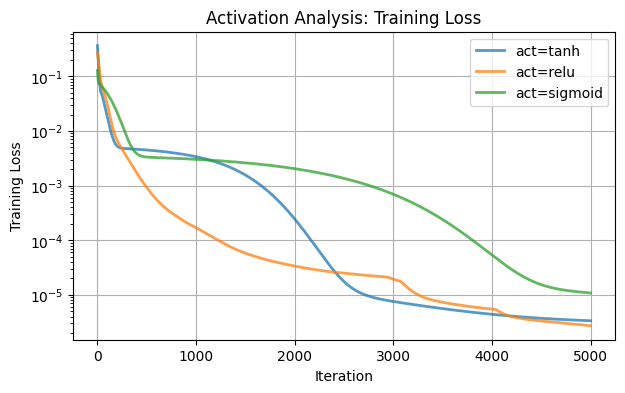

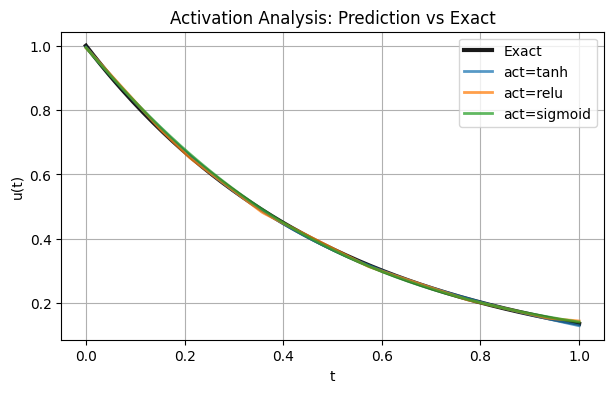

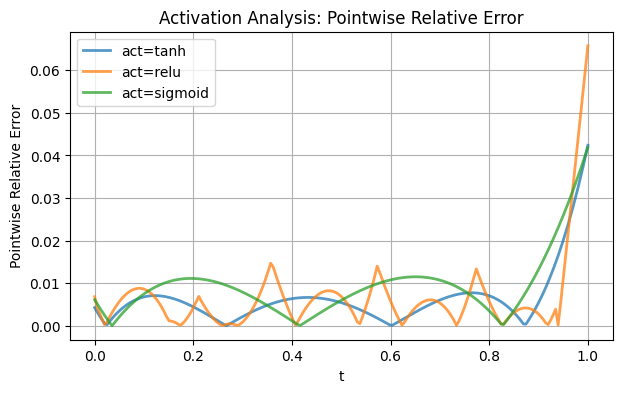

Setting              Relative L2 Error   
----------------------------------------
act=tanh             5.291088e-03        
act=relu             6.307792e-03        
act=sigmoid          7.919482e-03        


In [25]:
# ============================================================
# Activation Function Analysis
# ============================================================
activation_list = ["tanh", "relu", "sigmoid"]

act_results = {}
act_eval = {}

for act in activation_list:
    config = DEFAULT_CONFIG.copy()
    config["activation"] = act

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"act={act}"
    act_results[label] = loaded_result
    act_eval[label] = eval_out

plot_training_loss_comparison(
    act_results,
    title="Activation Analysis: Training Loss"
)

plot_prediction_vs_exact(
    act_eval,
    title="Activation Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    act_eval,
    title="Activation Analysis: Pointwise Relative Error"
)

print_relative_l2_table(act_eval)

## 6. K-Fold Cross Validation

In this section, we compare three validation settings:

- K = 1,
- K = 5,
- and Leave-One-Out Cross Validation (LOOCV).

The goal is to examine how the validation strategy affects the estimated model performance when the number of training samples is limited.

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k5_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k20_n20_it5000_seed0


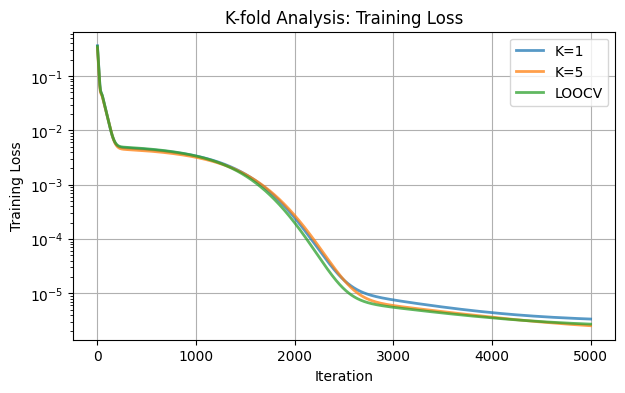

Setting              Mean Rel L2          Std Rel L2          
------------------------------------------------------------
K=1                  3.443556e-03         0.000000e+00        
K=5                  6.278952e-03         2.152727e-03        
LOOCV                7.323046e-03         8.732820e-03        


In [28]:
# ============================================================
# K-fold Cross Validation Analysis
# ============================================================
k_list = [1, 5, DEFAULT_CONFIG["train_size"]]   # K=1, K=5, LOOCV

cv_results = {}

for k in k_list:
    config = DEFAULT_CONFIG.copy()
    config["k_fold"] = k

    result = train_single_run(config)
    label = "LOOCV" if k == DEFAULT_CONFIG["train_size"] else f"K={k}"
    cv_results[label] = result



# training loss comparison
plot_training_loss_comparison(
    cv_results,
    title="K-fold Analysis: Training Loss"
)

# relative L2 comparison
labels = list(cv_results.keys())
values = [cv_results[label]["mean_val_rel_l2"] for label in labels]

print(f"{'Setting':<20} {'Mean Rel L2':<20} {'Std Rel L2':<20}")
print("-" * 60)
for label, result in cv_results.items():
    print(
        f"{label:<20} "
        f"{result['mean_val_rel_l2']:<20.6e} "
        f"{result['std_val_rel_l2']:<20.6e}"
    )

# 7. Physics-Informed Neural Networks

In this section, we extend the regression model to a Physics-Informed Neural Network (PINN). Unlike standard regression, PINN incorporates the governing differential equation into the training objective. The same MLP architecture is reused, but the loss function is modified to include a physics residual term and an initial condition term.

In [29]:
# ============================================================
# PINN setting
# ============================================================
PINN_DEFAULT_CONFIG = {
    "hidden_dim": 32,
    "depth": 1,
    "activation": "tanh",
    "optimizer": "Adam",
    "lr": 1e-3,
    "train_size": 0,          # number of observed data points
    "n_collocation": 100,     # number of collocation points
    "n_iters": 5000,
    "seed": 0,
}

### Collocation data points 
In this section, we implement the core components required for the forward PINN. These include collocation point generation, automatic differentiation for computing derivatives, the PINN loss function, and the training function.]

In [31]:
# ============================================================
# Collocation points
# - collocation points are sampled from [0,1]
# - no exact solution values are needed at these points
# ============================================================
def generate_collocation_points(n_collocation=100, t_min=T_MIN, t_max=T_MAX, seed=0):
    rng = np.random.default_rng(seed)
    t = rng.uniform(t_min, t_max, size=(n_collocation, 1))
    t = np.sort(t, axis=0)
    return torch.tensor(t, dtype=torch.float32)

In [32]:
# ============================================================
# Automatic differentiation helper
# - compute du/dt using torch.autograd.grad
# ============================================================
def compute_du_dt(model, t):
    # ============================================================
    # TODO:
    # Compute the derivative du/dt using automatic differentiation.
    #
    # Steps:
    # 1. Set t to require gradients
    # 2. Compute u_hat = model(t)
    # 3. Use torch.autograd.grad to compute du_dt
    #
    # Expected behavior:
    # - return both u_hat and du_dt
    # - du_dt should have the same shape as t
    # ============================================================
    t = t.clone().detach().to(device).requires_grad_(True)
    u_hat = model(t)
    du_dt = torch.autograd.grad(
        outputs=u_hat,
        inputs=t,
        grad_outputs=torch.ones_like(u_hat),
        create_graph=True
    )[0]
    return u_hat, du_dt

In [33]:
# ============================================================
# PINN loss
# - total loss = physics loss + data loss + initial condition loss
# ============================================================
def pinn_loss(model, t_collocation, t_data=None, u_data=None, a=A_TRUE):
    # ============================================================
    # TODO:
    # Implement the PINN loss.
    #
    # Components:
    # 1. Physics loss:
    #       mean(du/dt + a*u)^2
    # 2. Data loss (only if data are provided):
    #       mean((u_hat - u_data)^2)
    # 3. Initial condition loss:
    #       (u_hat(0) - 1)^2
    #
    # Expected behavior:
    # - If no data are provided, use only physics loss + IC loss
    # - Return:
    #     total_loss, physics_loss, data_loss, ic_loss
    # ============================================================
    # physics loss
    u_col, du_dt = compute_du_dt(model, t_collocation)
    residual = du_dt + a * u_col
    physics_loss = torch.mean(residual ** 2)

    # data loss
    if (t_data is not None) and (u_data is not None) and (len(t_data) > 0):
        t_data = t_data.to(device)
        u_data = u_data.to(device)
        u_pred_data = model(t_data)
        data_loss = torch.mean((u_pred_data - u_data) ** 2)
    else:
        data_loss = torch.tensor(0.0, dtype=torch.float32, device=device)

    # initial condition loss
    t0 = torch.tensor([[0.0]], dtype=torch.float32, device=device)
    u0_pred = model(t0)
    ic_loss = torch.mean((u0_pred - 1.0) ** 2)

    total_loss = physics_loss + data_loss + ic_loss
    return total_loss, physics_loss, data_loss, ic_loss

Results for PINN experiments are stored separately under results/pinn. Each configuration is saved in its own subdirectory so that repeated runs can be skipped automatically.

In [34]:
# ============================================================
# Result directory for PINN
# ============================================================
PINN_RESULT_ROOT = Path("results/pinn")
PINN_RESULT_ROOT.mkdir(parents=True, exist_ok=True)

def make_pinn_run_name(config):
    return (
        f"h{config['hidden_dim']}_"
        f"d{config['depth']}_"
        f"act{config['activation']}_"
        f"opt{config['optimizer']}_"
        f"lr{config['lr']}_"
        f"ndata{config['train_size']}_"
        f"ncol{config['n_collocation']}_"
        f"it{config['n_iters']}_"
        f"seed{config['seed']}"
    )

This function trains a forward PINN for one configuration. It saves the trained parameters and the recorded loss history. If the same setting has already been trained, the function loads the saved result and skips retraining.

In [36]:
def train_single_pinn_run(config):
    run_name = make_pinn_run_name(config)
    run_dir = PINN_RESULT_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    model_path = run_dir / "model.pt"
    result_path = run_dir / "result.json"

    if model_path.exists() and result_path.exists():
        print(f"[SKIP] Already trained: {run_name}")
        with open(result_path, "r", encoding="utf-8") as f:
            result = json.load(f)
        return result

    print(f"[TRAIN] Start: {run_name}")
    set_seed(config["seed"])

    # observed data (optional)
    if config["train_size"] > 0:
        t_data, u_data = generate_train_data(
            n_train=config["train_size"],
            a=A_TRUE,
            seed=config["seed"]
        )
    else:
        t_data, u_data = None, None

    # collocation points
    t_collocation = generate_collocation_points(
        n_collocation=config["n_collocation"],
        seed=config["seed"]
    ).to(device)

    model = MLP(
        hidden_dim=config["hidden_dim"],
        depth=config["depth"],
        activation=config["activation"]
    ).to(device)

    optimizer = build_optimizer(
        model,
        optimizer_name=config["optimizer"],
        lr=config["lr"]
    )

    history = {
        "iter": [],
        "train_loss": [],
        "physics_loss": [],
        "data_loss": [],
        "ic_loss": [],
        "elapsed_time": [],
    }

    start_time = time.time()
    log_every = max(1, config["n_iters"] // 10)

    # ============================================================
    # TODO:
    # Implement the PINN training loop.
    #
    # At each iteration:
    # 1. Set the model to train mode
    # 2. Clear gradients
    # 3. Compute total PINN loss
    # 4. Backpropagate
    # 5. Update parameters
    # 6. Save total loss, physics loss, data loss, IC loss, and elapsed time
    #
    # Logging:
    # - Print every n_iters // 10 iterations:
    #   [current_iter / total_iter]
    #   Train loss: ...
    #   Physics loss: ...
    #   Data loss: ...
    #   IC loss: ...
    #   Training time: ...
    # ============================================================
    for it in range(1, config["n_iters"] + 1):
        model.train()
        optimizer.zero_grad()

        total_loss, physics_loss, data_loss, ic_loss = pinn_loss(
            model=model,
            t_collocation=t_collocation,
            t_data=t_data,
            u_data=u_data,
            a=A_TRUE
        )

        total_loss.backward()
        optimizer.step()

        elapsed = time.time() - start_time

        history["iter"].append(it)
        history["train_loss"].append(total_loss.item())
        history["physics_loss"].append(physics_loss.item())
        history["data_loss"].append(data_loss.item())
        history["ic_loss"].append(ic_loss.item())
        history["elapsed_time"].append(elapsed)

        if (it % log_every == 0) or (it == config["n_iters"]):
            print(
                f"[{it}/{config['n_iters']}] "
                f"Train loss: {total_loss.item():.6e}, "
                f"Physics loss: {physics_loss.item():.6e}, "
                f"Data loss: {data_loss.item():.6e}, "
                f"IC loss: {ic_loss.item():.6e}, "
                f"Training time: {elapsed:.2f}s"
            )

    torch.save(model.state_dict(), model_path)

    result = {
        "config": config,
        "history": history
    }

    with open(result_path, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    print(f"[DONE] Saved to: {run_dir}")
    return result

### Basic Forward PINN Run

We first run one default PINN experiment to verify that the full forward PINN pipeline works correctly

In [37]:
pinn_default_result = train_single_pinn_run(PINN_DEFAULT_CONFIG)

[TRAIN] Start: h32_d1_acttanh_optAdam_lr0.001_ndata0_ncol100_it5000_seed0
[500/5000] Train loss: 3.321739e-02, Physics loss: 2.586344e-02, Data loss: 0.000000e+00, IC loss: 7.353949e-03, Training time: 1.06s
[1000/5000] Train loss: 2.534472e-03, Physics loss: 2.486127e-03, Data loss: 0.000000e+00, IC loss: 4.834505e-05, Training time: 1.97s
[1500/5000] Train loss: 9.423676e-04, Physics loss: 9.340214e-04, Data loss: 0.000000e+00, IC loss: 8.346191e-06, Training time: 2.91s
[2000/5000] Train loss: 6.029577e-04, Physics loss: 6.007013e-04, Data loss: 0.000000e+00, IC loss: 2.256473e-06, Training time: 3.89s
[2500/5000] Train loss: 4.896804e-04, Physics loss: 4.886178e-04, Data loss: 0.000000e+00, IC loss: 1.062554e-06, Training time: 4.92s
[3000/5000] Train loss: 4.042197e-04, Physics loss: 4.035336e-04, Data loss: 0.000000e+00, IC loss: 6.861235e-07, Training time: 5.94s
[3500/5000] Train loss: 3.290147e-04, Physics loss: 3.285350e-04, Data loss: 0.000000e+00, IC loss: 4.797030e-07, Tra

In [38]:
def load_pinn_result(config):
    run_name = make_pinn_run_name(config)
    run_dir = PINN_RESULT_ROOT / run_name
    result_path = run_dir / "result.json"
    model_path = run_dir / "model.pt"

    if not result_path.exists():
        raise FileNotFoundError(f"Result file not found: {result_path}")
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")

    with open(result_path, "r", encoding="utf-8") as f:
        result = json.load(f)

    model = MLP(
        hidden_dim=config["hidden_dim"],
        depth=config["depth"],
        activation=config["activation"]
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    return result, model

In [39]:
def evaluate_pinn_model(model, t_min=0.0, t_max=1.0, n_eval=200):
    t_grid = np.linspace(t_min, t_max, n_eval).reshape(-1, 1)
    u_exact = exact_solution(t_grid, a=A_TRUE)

    t_tensor = torch.tensor(t_grid, dtype=torch.float32).to(device)
    u_exact_tensor = torch.tensor(u_exact, dtype=torch.float32).to(device)

    with torch.no_grad():
        u_pred = model(t_tensor)

    rel_l2 = relative_l2_error(u_pred, u_exact_tensor)
    pw_rel = pointwise_relative_error(u_pred, u_exact_tensor).detach().cpu().numpy()

    return {
        "t": t_grid,
        "u_exact": u_exact,
        "u_pred": u_pred.detach().cpu().numpy(),
        "pointwise_rel_error": pw_rel,
        "relative_l2": rel_l2
    }

## Forward PINN Analysis - Training Loss

Plot the training loss curve and analyze the convergence behavior of the forward PINN

In [40]:
def evaluate_pinn_model(model, t_min=0.0, t_max=1.0, n_eval=200):
    t_grid = np.linspace(t_min, t_max, n_eval).reshape(-1, 1)
    u_exact = exact_solution(t_grid, a=A_TRUE)

    t_tensor = torch.tensor(t_grid, dtype=torch.float32).to(device)
    u_exact_tensor = torch.tensor(u_exact, dtype=torch.float32).to(device)

    with torch.no_grad():
        u_pred = model(t_tensor)

    rel_l2 = relative_l2_error(u_pred, u_exact_tensor)
    pw_rel = pointwise_relative_error(u_pred, u_exact_tensor).detach().cpu().numpy()

    return {
        "t": t_grid,
        "u_exact": u_exact,
        "u_pred": u_pred.detach().cpu().numpy(),
        "pointwise_rel_error": pw_rel,
        "relative_l2": rel_l2
    }

## Forward PINN Analysis 2 : Interpolation and Extrapolation

Evaluate the trained PINN on three scenarios: interpolation on given samples, interpolation on unseen samples in the same domain, and extrapolation on a new domain. Plot the prediction, exact solution, pointwise relative error, and report the relative $L_2$ error.

In [41]:
_, pinn_model = load_pinn_result(PINN_DEFAULT_CONFIG)

# interpolation on given samples
if PINN_DEFAULT_CONFIG["train_size"] > 0:
    t_given, u_given = generate_train_data(
        n_train=PINN_DEFAULT_CONFIG["train_size"],
        a=A_TRUE,
        seed=PINN_DEFAULT_CONFIG["seed"]
    )
    with torch.no_grad():
        u_given_pred = pinn_model(t_given.to(device))
    rel_l2_given = relative_l2_error(u_given_pred, u_given.to(device))
    pw_given = pointwise_relative_error(u_given_pred, u_given.to(device)).cpu().numpy()
else:
    t_given, u_given, rel_l2_given, pw_given = None, None, None, None

# interpolation on unseen samples
interp_out = evaluate_pinn_model(pinn_model, t_min=0.0, t_max=1.0, n_eval=200)

# extrapolation
extra_out = evaluate_pinn_model(pinn_model, t_min=1.0, t_max=2.0, n_eval=200)

print("Interpolation on given samples - Relative L2:", rel_l2_given)
print("Interpolation on unseen samples - Relative L2:", interp_out["relative_l2"])
print("Extrapolation on [1,2] - Relative L2:", extra_out["relative_l2"])

Interpolation on given samples - Relative L2: None
Interpolation on unseen samples - Relative L2: 0.0028762707952409983
Extrapolation on [1,2] - Relative L2: 0.39721667766571045


/tmp/ipykernel_13158/3222824339.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


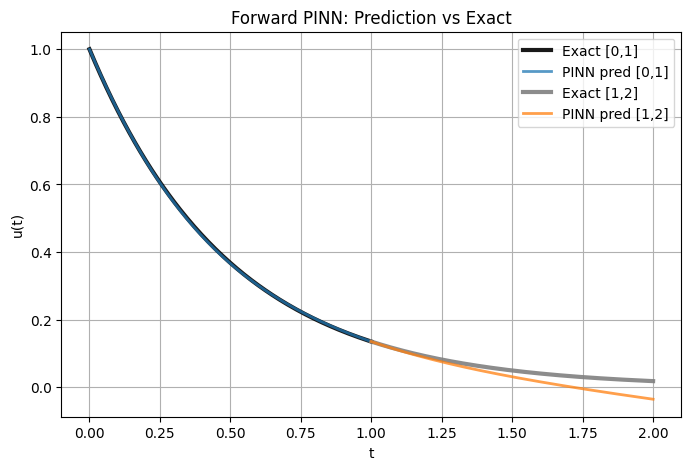

In [42]:
# prediction vs exact
plt.figure(figsize=(8, 5))

plt.plot(interp_out["t"], interp_out["u_exact"], color="black", linewidth=3.0, alpha=0.9, label="Exact [0,1]")
plt.plot(interp_out["t"], interp_out["u_pred"], linewidth=2.0, alpha=0.75, label="PINN pred [0,1]")

plt.plot(extra_out["t"], extra_out["u_exact"], color="gray", linewidth=3.0, alpha=0.9, label="Exact [1,2]")
plt.plot(extra_out["t"], extra_out["u_pred"], linewidth=2.0, alpha=0.75, label="PINN pred [1,2]")

if t_given is not None:
    plt.scatter(t_given.numpy(), u_given.numpy(), color="red", s=35, alpha=0.8, label="Given samples")

plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Forward PINN: Prediction vs Exact")
plt.legend()
plt.grid(True)
plt.show()

## Forward PINN Analysis 3 : Effect of the number of collocation points

Investigate how the number of collocation points affects the final prediction accuracy. Train the PINN with $N_c = 10, 20, 50, 100 ,200$  and compare the relative $L_2$ errors.

In [43]:
collocation_list = [10, 20, 50, 100, 200]

collocation_results = {}
collocation_rel_l2 = {}

for n_col in collocation_list:
    config = PINN_DEFAULT_CONFIG.copy()
    config["n_collocation"] = n_col

    train_single_pinn_run(config)
    _, model = load_pinn_result(config)
    eval_out = evaluate_pinn_model(model, t_min=0.0, t_max=1.0, n_eval=200)

    label = f"Nc={n_col}"
    collocation_results[label] = config
    collocation_rel_l2[label] = eval_out["relative_l2"]

print(f"{'Setting':<20} {'Relative L2 Error':<20}")
print("-" * 40)
for label, val in collocation_rel_l2.items():
    print(f"{label:<20} {val:<20.6e}")

[TRAIN] Start: h32_d1_acttanh_optAdam_lr0.001_ndata0_ncol10_it5000_seed0
[500/5000] Train loss: 4.013525e-02, Physics loss: 2.989872e-02, Data loss: 0.000000e+00, IC loss: 1.023653e-02, Training time: 0.99s
[1000/5000] Train loss: 1.958477e-03, Physics loss: 1.922189e-03, Data loss: 0.000000e+00, IC loss: 3.628861e-05, Training time: 1.95s
[1500/5000] Train loss: 7.358254e-04, Physics loss: 7.305924e-04, Data loss: 0.000000e+00, IC loss: 5.232961e-06, Training time: 2.87s
[2000/5000] Train loss: 5.306767e-04, Physics loss: 5.292046e-04, Data loss: 0.000000e+00, IC loss: 1.472126e-06, Training time: 3.80s
[2500/5000] Train loss: 4.456116e-04, Physics loss: 4.448284e-04, Data loss: 0.000000e+00, IC loss: 7.832423e-07, Training time: 4.82s
[3000/5000] Train loss: 3.728048e-04, Physics loss: 3.722672e-04, Data loss: 0.000000e+00, IC loss: 5.376648e-07, Training time: 5.79s
[3500/5000] Train loss: 3.086376e-04, Physics loss: 3.082526e-04, Data loss: 0.000000e+00, IC loss: 3.850008e-07, Trai

/tmp/ipykernel_13158/3222824339.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


[500/5000] Train loss: 3.568758e-02, Physics loss: 2.631467e-02, Data loss: 0.000000e+00, IC loss: 9.372911e-03, Training time: 0.91s
[1000/5000] Train loss: 2.412636e-03, Physics loss: 2.361440e-03, Data loss: 0.000000e+00, IC loss: 5.119575e-05, Training time: 1.82s
[1500/5000] Train loss: 8.532812e-04, Physics loss: 8.458084e-04, Data loss: 0.000000e+00, IC loss: 7.472830e-06, Training time: 2.75s
[2000/5000] Train loss: 5.880318e-04, Physics loss: 5.861485e-04, Data loss: 0.000000e+00, IC loss: 1.883310e-06, Training time: 3.68s
[2500/5000] Train loss: 4.889542e-04, Physics loss: 4.880230e-04, Data loss: 0.000000e+00, IC loss: 9.312234e-07, Training time: 4.60s
[3000/5000] Train loss: 4.057496e-04, Physics loss: 4.051285e-04, Data loss: 0.000000e+00, IC loss: 6.210900e-07, Training time: 5.54s
[3500/5000] Train loss: 3.329076e-04, Physics loss: 3.324720e-04, Data loss: 0.000000e+00, IC loss: 4.356029e-07, Training time: 6.45s
[4000/5000] Train loss: 2.718515e-04, Physics loss: 2.71

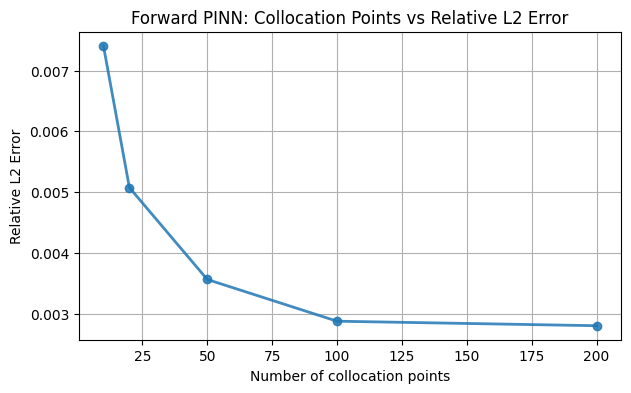

In [44]:
plt.figure(figsize=(7, 4))
plt.plot(
    [int(k.split("=")[1]) for k in collocation_rel_l2.keys()],
    list(collocation_rel_l2.values()),
    marker="o",
    linewidth=2.0,
    alpha=0.85
)
plt.xlabel("Number of collocation points")
plt.ylabel("Relative L2 Error")
plt.title("Forward PINN: Collocation Points vs Relative L2 Error")
plt.grid(True)
plt.show()

## Forward PINN Analysis 4: Effect of Observed Data

Investigate how adding observed data affects the forward PINN. Train the model with $N_{data}=0,5,10$ and compare the relative $L_2$ errors.

In [47]:
ndata_list = [0, 5, 10]

ndata_rel_l2 = {}

for n_data in ndata_list:
    config = PINN_DEFAULT_CONFIG.copy()
    config["train_size"] = n_data
    config["n_collocation"] = 20

    train_single_pinn_run(config)
    _, model = load_pinn_result(config)
    eval_out = evaluate_pinn_model(model, t_min=0.0, t_max=1.0, n_eval=200)

    label = f"Ndata={n_data}"
    ndata_rel_l2[label] = eval_out["relative_l2"]

print(f"{'Setting':<20} {'Relative L2 Error':<20}")
print("-" * 40)
for label, val in ndata_rel_l2.items():
    print(f"{label:<20} {val:<20.6e}")

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_ndata0_ncol20_it5000_seed0
[TRAIN] Start: h32_d1_acttanh_optAdam_lr0.001_ndata5_ncol20_it5000_seed0


/tmp/ipykernel_13158/3222824339.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


[500/5000] Train loss: 6.110533e-02, Physics loss: 4.812667e-02, Data loss: 2.801882e-03, IC loss: 1.017678e-02, Training time: 1.05s
[1000/5000] Train loss: 3.022274e-03, Physics loss: 2.897540e-03, Data loss: 9.510708e-05, IC loss: 2.962730e-05, Training time: 2.09s
[1500/5000] Train loss: 1.064461e-03, Physics loss: 1.032921e-03, Data loss: 2.813924e-05, IC loss: 3.400515e-06, Training time: 3.17s
[2000/5000] Train loss: 6.160748e-04, Physics loss: 6.026710e-04, Data loss: 1.285060e-05, IC loss: 5.531592e-07, Training time: 4.25s
[2500/5000] Train loss: 4.997418e-04, Physics loss: 4.901245e-04, Data loss: 9.475351e-06, IC loss: 1.419488e-07, Training time: 5.40s
[3000/5000] Train loss: 4.325377e-04, Physics loss: 4.243730e-04, Data loss: 8.102142e-06, IC loss: 6.252074e-08, Training time: 6.48s
[3500/5000] Train loss: 3.730679e-04, Physics loss: 3.659922e-04, Data loss: 7.039710e-06, IC loss: 3.601690e-08, Training time: 7.50s
[4000/5000] Train loss: 3.185626e-04, Physics loss: 3.12

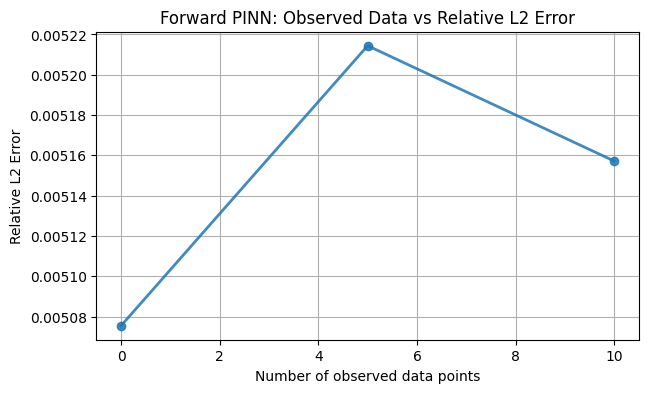

In [48]:
plt.figure(figsize=(7, 4))
plt.plot(
    [int(k.split("=")[1]) for k in ndata_rel_l2.keys()],
    list(ndata_rel_l2.values()),
    marker="o",
    linewidth=2.0,
    alpha=0.85
)
plt.xlabel("Number of observed data points")
plt.ylabel("Relative L2 Error")
plt.title("Forward PINN: Observed Data vs Relative L2 Error")
plt.grid(True)
plt.show()

## appendix



In [49]:
# ============================================================
# Regression model loader
# ============================================================
def load_regression_result(config):
    run_name = make_run_name(config)
    run_dir = RESULT_ROOT / run_name
    result_path = run_dir / "result.json"
    model_path = run_dir / "model.pt"

    if not result_path.exists():
        raise FileNotFoundError(f"Result file not found: {result_path}")
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")

    with open(result_path, "r", encoding="utf-8") as f:
        result = json.load(f)

    model = MLP(
        hidden_dim=config["hidden_dim"],
        depth=config["depth"],
        activation=config["activation"]
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    return result, model


# ============================================================
# Evaluate any model on a given domain
# ============================================================
def evaluate_any_model(model, t_min=0.0, t_max=1.0, n_eval=200, a=A_TRUE):
    t = np.linspace(t_min, t_max, n_eval).reshape(-1, 1)
    u_exact = exact_solution(t, a=a)

    t_tensor = torch.tensor(t, dtype=torch.float32).to(device)
    u_exact_tensor = torch.tensor(u_exact, dtype=torch.float32).to(device)

    with torch.no_grad():
        u_pred = model(t_tensor)

    rel_l2 = relative_l2_error(u_pred, u_exact_tensor)
    pw_rel = pointwise_relative_error(u_pred, u_exact_tensor).detach().cpu().numpy()

    return {
        "t": t,
        "u_exact": u_exact,
        "u_pred": u_pred.detach().cpu().numpy(),
        "pointwise_rel_error": pw_rel,
        "relative_l2": rel_l2
    }

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_ndata0_ncol100_it5000_seed0


/tmp/ipykernel_13158/1145552957.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
/tmp/ipykernel_13158/

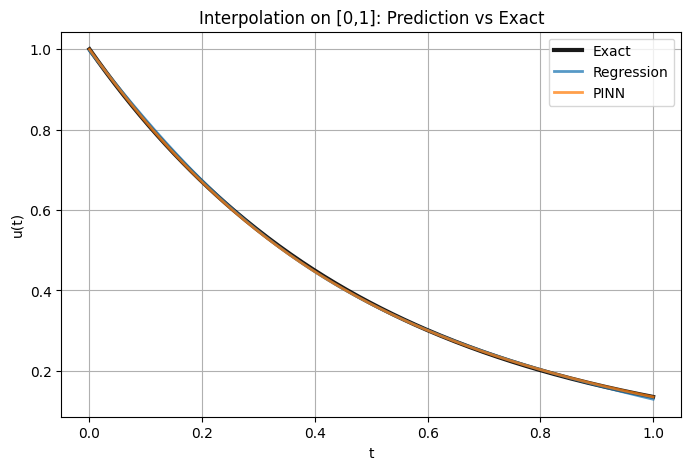

In [52]:
# ============================================================
# Choose the regression configuration to compare
# ============================================================
REG_COMPARE_CONFIG = DEFAULT_CONFIG.copy()
REG_COMPARE_CONFIG["optimizer"] = "Adam"
REG_COMPARE_CONFIG["lr"] = 1e-3
REG_COMPARE_CONFIG["hidden_dim"] = 32
REG_COMPARE_CONFIG["depth"] = 1
REG_COMPARE_CONFIG["activation"] = "tanh"
REG_COMPARE_CONFIG["train_size"] = 20
REG_COMPARE_CONFIG["k_fold"] = 1
REG_COMPARE_CONFIG["n_iters"] = 5000
REG_COMPARE_CONFIG["seed"] = 0

# ============================================================
# Choose the PINN configuration to compare
# ============================================================
PINN_COMPARE_CONFIG = PINN_DEFAULT_CONFIG.copy()
PINN_COMPARE_CONFIG["optimizer"] = "Adam"
PINN_COMPARE_CONFIG["lr"] = 1e-3
PINN_COMPARE_CONFIG["hidden_dim"] = 32
PINN_COMPARE_CONFIG["depth"] = 1
PINN_COMPARE_CONFIG["activation"] = "tanh"
PINN_COMPARE_CONFIG["train_size"] = 0        # default PINN setting
PINN_COMPARE_CONFIG["n_collocation"] = 100
PINN_COMPARE_CONFIG["n_iters"] = 5000
PINN_COMPARE_CONFIG["seed"] = 0

# If needed, train first
train_single_run(REG_COMPARE_CONFIG)
train_single_pinn_run(PINN_COMPARE_CONFIG)

# Load trained models
_, reg_model = load_regression_result(REG_COMPARE_CONFIG)
_, pinn_model = load_pinn_result(PINN_COMPARE_CONFIG)

# ============================================================
# Interpolation domain: [0,1]
# ============================================================
reg_interp = evaluate_any_model(reg_model, t_min=0.0, t_max=1.0, n_eval=200, a=A_TRUE)
pinn_interp = evaluate_any_model(pinn_model, t_min=0.0, t_max=1.0, n_eval=200, a=A_TRUE)

# ============================================================
# Extrapolation domain: [1,2]
# ============================================================
reg_extra = evaluate_any_model(reg_model, t_min=1.0, t_max=2.0, n_eval=200, a=A_TRUE)
pinn_extra = evaluate_any_model(pinn_model, t_min=1.0, t_max=2.0, n_eval=200, a=A_TRUE)

plt.figure(figsize=(8, 5))

plt.plot(
    reg_interp["t"], reg_interp["u_exact"],
    color="black", linewidth=3.0, alpha=0.9, label="Exact"
)

plt.plot(
    reg_interp["t"], reg_interp["u_pred"],
    linewidth=2.0, alpha=0.75, label="Regression"
)

plt.plot(
    pinn_interp["t"], pinn_interp["u_pred"],
    linewidth=2.0, alpha=0.75, label="PINN"
)

plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Interpolation on [0,1]: Prediction vs Exact")
plt.legend()
plt.grid(True)
plt.show()

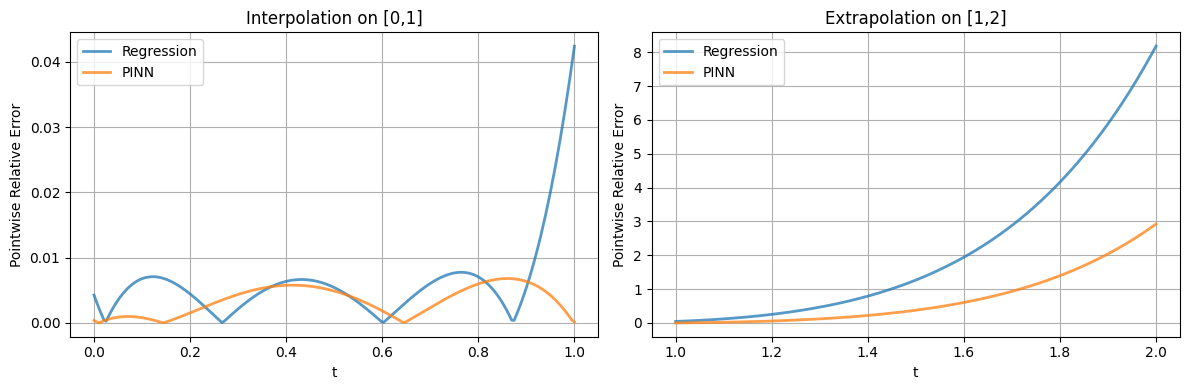

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Interpolation
axes[0].plot(
    reg_interp["t"], reg_interp["pointwise_rel_error"],
    linewidth=2.0, alpha=0.75, label="Regression"
)
axes[0].plot(
    pinn_interp["t"], pinn_interp["pointwise_rel_error"],
    linewidth=2.0, alpha=0.75, label="PINN"
)
axes[0].set_title("Interpolation on [0,1]")
axes[0].set_xlabel("t")
axes[0].set_ylabel("Pointwise Relative Error")
axes[0].grid(True)
axes[0].legend()

# Extrapolation
axes[1].plot(
    reg_extra["t"], reg_extra["pointwise_rel_error"],
    linewidth=2.0, alpha=0.75, label="Regression"
)
axes[1].plot(
    pinn_extra["t"], pinn_extra["pointwise_rel_error"],
    linewidth=2.0, alpha=0.75, label="PINN"
)
axes[1].set_title("Extrapolation on [1,2]")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Pointwise Relative Error")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [55]:
comparison_table = {
    "Regression (Interpolation)": reg_interp["relative_l2"],
    "PINN (Interpolation)": pinn_interp["relative_l2"],
    "Regression (Extrapolation)": reg_extra["relative_l2"],
    "PINN (Extrapolation)": pinn_extra["relative_l2"],
}

print(f"{'Setting':<30} {'Relative L2 Error':<20}")
print("-" * 55)
for key, value in comparison_table.items():
    print(f"{key:<30} {value:<20.6e}")

Setting                        Relative L2 Error   
-------------------------------------------------------
Regression (Interpolation)     5.291088e-03        
PINN (Interpolation)           2.876271e-03        
Regression (Extrapolation)     1.198444e+00        
PINN (Extrapolation)           3.972167e-01        
